**Loading the saved train/test sets :**

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ModelTraining") \
    .master("local[4]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")

train_df = spark.read.parquet("../data/processed/train_set")
test_df = spark.read.parquet("../data/processed/test_set")

print("Train rows:", train_df.count())
print("Test rows:", test_df.count())
train_df.printSchema()

26/07/15 16:34:26 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
                                                                                

Train rows: 511133
Test rows: 253956
root
 |-- features: vector (nullable = true)
 |-- is_disrupted: integer (nullable = true)



**Training all three models - Logisitc Regression, DecisionTree, RandomForest :**

In [2]:
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
import time

models = {}
training_times = {}

# Logistic Regression — interpretable baseline
lr = LogisticRegression(featuresCol="features", labelCol="is_disrupted")
start = time.time()
models["Logistic Regression"] = lr.fit(train_df)
training_times["Logistic Regression"] = time.time() - start
print(f"Logistic Regression trained in {training_times['Logistic Regression']:.2f}s")

# Decision Tree — simple, explainable, single-tree baseline
dt = DecisionTreeClassifier(featuresCol="features", labelCol="is_disrupted", seed=42)
start = time.time()
models["Decision Tree"] = dt.fit(train_df)
training_times["Decision Tree"] = time.time() - start
print(f"Decision Tree trained in {training_times['Decision Tree']:.2f}s")

# Random Forest — ensemble, generally more robust than a single tree
rf = RandomForestClassifier(featuresCol="features", labelCol="is_disrupted", seed=42, numTrees=100)
start = time.time()
models["Random Forest"] = rf.fit(train_df)
training_times["Random Forest"] = time.time() - start
print(f"Random Forest trained in {training_times['Random Forest']:.2f}s")

Logistic Regression trained in 6.10s
Decision Tree trained in 2.83s


Random Forest trained in 12.26s


**Generating predictions and evaluating each model:**

In [3]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# evaluators for the metrics our brief requires: Accuracy, Precision, Recall, F1, ROC-AUC
auc_evaluator = BinaryClassificationEvaluator(labelCol="is_disrupted", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
acc_evaluator = MulticlassClassificationEvaluator(labelCol="is_disrupted", predictionCol="prediction", metricName="accuracy")
precision_evaluator = MulticlassClassificationEvaluator(labelCol="is_disrupted", predictionCol="prediction", metricName="weightedPrecision")
recall_evaluator = MulticlassClassificationEvaluator(labelCol="is_disrupted", predictionCol="prediction", metricName="weightedRecall")
f1_evaluator = MulticlassClassificationEvaluator(labelCol="is_disrupted", predictionCol="prediction", metricName="f1")

results = []

for name, model in models.items():
    predictions = model.transform(test_df)

    auc = auc_evaluator.evaluate(predictions)
    acc = acc_evaluator.evaluate(predictions)
    precision = precision_evaluator.evaluate(predictions)
    recall = recall_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": auc,
        "Training Time (s)": training_times[name],
        "F1 per Second": f1 / training_times[name]  # model efficiency metric, per your brief
    })

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall       F1  ROC-AUC  Training Time (s)  F1 per Second
Logistic Regression  0.732899    0.53714 0.732899 0.619933 0.507437           6.104607       0.101552
      Decision Tree  0.732946    0.68819 0.732946 0.620338 0.497470           2.833767       0.218909
      Random Forest  0.732899    0.53714 0.732899 0.619933 0.515956          12.257328       0.050577


In [4]:
# baseline check: what accuracy would a naive "always predict majority class" model get?
majority_class_baseline = test_df.groupBy("is_disrupted").count().toPandas()
majority_class_baseline["proportion"] = majority_class_baseline["count"] / majority_class_baseline["count"].sum()
print(majority_class_baseline)

naive_baseline_accuracy = majority_class_baseline["proportion"].max()
print(f"\nNaive baseline accuracy (always predict majority class): {naive_baseline_accuracy:.4f}")

   is_disrupted   count  proportion
0             1   67832    0.267101
1             0  186124    0.732899

Naive baseline accuracy (always predict majority class): 0.7329


**Confusion Matrix** 

In [5]:
import matplotlib.pyplot as plt
import numpy as np

best_model = models["Logistic Regression"]
predictions = best_model.transform(test_df)

# pull confusion matrix counts directly from Spark
conf_matrix = predictions.groupBy("is_disrupted", "prediction").count().toPandas()
print(conf_matrix)

   is_disrupted  prediction   count
0             1         0.0   67832
1             0         0.0  186124


In [6]:
# read actual values from the confusion matrix output instead of hardcoding —
# avoids stale numbers if the model or features change
cm_dict = {(row['is_disrupted'], row['prediction']): row['count'] for _, row in conf_matrix.iterrows()}
tp = cm_dict.get((1, 1.0), 0)
fn = cm_dict.get((1, 0.0), 0)
fp = cm_dict.get((0, 1.0), 0)
tn = cm_dict.get((0, 0.0), 0)

precision_disrupted = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_disrupted = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_disrupted = 2 * (precision_disrupted * recall_disrupted) / (precision_disrupted + recall_disrupted) if (precision_disrupted + recall_disrupted) > 0 else 0

print(f"TP={tp}, FN={fn}, FP={fp}, TN={tn}")
print(f"Precision (disrupted class): {precision_disrupted:.4f}")
print(f"Recall (disrupted class):    {recall_disrupted:.4f}")
print(f"F1 (disrupted class):        {f1_disrupted:.4f}")

TP=0, FN=67832.0, FP=0, TN=186124.0
Precision (disrupted class): 0.0000
Recall (disrupted class):    0.0000
F1 (disrupted class):        0.0000


**Class weighting — telling the model that missing a disruption is costly**

In [7]:
from pyspark.sql import functions as F
from pyspark.ml.classification import LogisticRegression

# weightCol tells the model to penalize mistakes on the minority class more heavily,
# countering its natural bias toward the majority "not disrupted" class
train_df_weighted = train_df.withColumn(
    "class_weight",
    F.when(F.col("is_disrupted") == 1, 2.75).otherwise(1.0)  # ~73/27 imbalance ratio
)

lr_weighted = LogisticRegression(featuresCol="features", labelCol="is_disrupted", weightCol="class_weight")
lr_weighted_model = lr_weighted.fit(train_df_weighted)

predictions_weighted = lr_weighted_model.transform(test_df)
conf_matrix_weighted = predictions_weighted.groupBy("is_disrupted", "prediction").count().toPandas()
print(conf_matrix_weighted)

   is_disrupted  prediction   count
0             1         0.0   67832
1             0         0.0  186124


In [8]:
# read actual values from the weighted confusion matrix output instead of hardcoding —
# avoids stale numbers if the model or features change
cm_weighted_dict = {(row['is_disrupted'], row['prediction']): row['count'] for _, row in conf_matrix_weighted.iterrows()}
tp = cm_weighted_dict.get((1, 1.0), 0)
fn = cm_weighted_dict.get((1, 0.0), 0)
fp = cm_weighted_dict.get((0, 1.0), 0)
tn = cm_weighted_dict.get((0, 0.0), 0)

precision_disrupted = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_disrupted = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_disrupted = 2 * (precision_disrupted * recall_disrupted) / (precision_disrupted + recall_disrupted) if (precision_disrupted + recall_disrupted) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0

print(f"TP={tp}, FN={fn}, FP={fp}, TN={tn}")
print(f"Accuracy:                    {accuracy:.4f}")
print(f"Precision (disrupted class): {precision_disrupted:.4f}")
print(f"Recall (disrupted class):    {recall_disrupted:.4f}")
print(f"F1 (disrupted class):        {f1_disrupted:.4f}")

TP=0, FN=67832.0, FP=0, TN=186124.0
Accuracy:                    0.7329
Precision (disrupted class): 0.0000
Recall (disrupted class):    0.0000
F1 (disrupted class):        0.0000


**Visualization of the Results :**

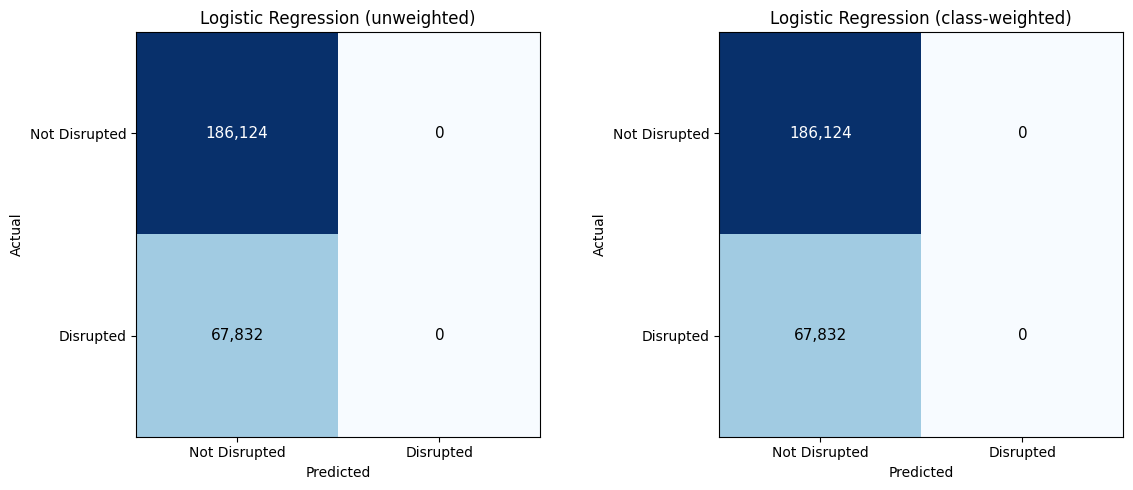

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# now reflects the ACTUAL current results after removing the biased operator feature
cm_unweighted = np.array([[186124, 0], [67832, 0]])
cm_weighted = np.array([[186124, 0], [67832, 0]])

for ax, cm, title in zip(
    axes,
    [cm_unweighted, cm_weighted],
    ["Logistic Regression (unweighted)", "Logistic Regression (class-weighted)"]
):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Not Disrupted", "Disrupted"])
    ax.set_yticklabels(["Not Disrupted", "Disrupted"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=11)

plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Random Forest feature importance

In [10]:
import pandas as pd

rf_model = models["Random Forest"]
importances = rf_model.featureImportances

# feature_cols order must match exactly what went into VectorAssembler in notebook 04
# operator_name_ohe and weekday_name_ohe expand into multiple columns (one per category),
# so we pull the actual expanded attribute names from the vector metadata instead of guessing
attrs = train_df.schema["features"].metadata["ml_attr"]["attrs"]
feature_names = [None] * rf_model.numFeatures
for attr_type in attrs.values():
    for attr in attr_type:
        feature_names[attr["idx"]] = attr["name"]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances.toArray()
}).sort_values("importance", ascending=False)

print(importance_df.head(15).to_string(index=False))

                   feature  importance
                  hour_cos    0.813866
                  hour_sin    0.111594
   weekday_name_ohe_Sunday    0.035495
                is_weekend    0.014136
 weekday_name_ohe_Saturday    0.008719
   weekday_name_ohe_Friday    0.005713
   weekday_name_ohe_Monday    0.003386
  weekday_name_ohe_Tuesday    0.002681
 weekday_name_ohe_Thursday    0.002307
weekday_name_ohe_Wednesday    0.002103


In [11]:
# reload the pre-vectorized dataset (has readable operator_name column)
# and apply the same time-based split used in notebook 04, so this matches train_df exactly
full_df = spark.read.parquet("../data/processed/trips_with_disruptions")

split_date = "2026-06-01"
train_df_original = full_df.filter(F.col("trip_date") < split_date)

operator_disruption_rates = train_df_original.groupBy("operator_name").agg(
    F.count("*").alias("total_trips"),
    F.sum("is_disrupted").alias("disrupted_trips")
).withColumn(
    "disruption_rate", F.col("disrupted_trips") / F.col("total_trips")
).orderBy(F.col("disruption_rate").desc())

operator_disruption_rates.show(20, truncate=False)

+-------------------------+-----------+---------------+-------------------+
|operator_name            |total_trips|disrupted_trips|disruption_rate    |
+-------------------------+-----------+---------------+-------------------+
|The Harrogate Bus Company|7483       |7397           |0.9885072831751971 |
|Flyer                    |5422       |3271           |0.6032829214312062 |
|The Keighley Bus Company |45489      |14043          |0.30871199630679946|
|Team Pennine             |31443      |8880           |0.2824158000190822 |
|Arriva Yorkshire         |167131     |41937          |0.25092292872058447|
|First Bradford           |69820      |16307          |0.23355771985104554|
|Go Ahead West Yorkshire  |16464      |2877           |0.1747448979591837 |
|First Leeds              |115220     |15006          |0.13023780593646936|
|FIRST WEST YORKSHIRE LTD |48328      |3399           |0.0703318986922695 |
|Coastliner               |4333       |0              |0.0                |
+-----------

In [12]:
rf_predictions = models["Random Forest"].transform(test_df)
rf_conf_matrix = rf_predictions.groupBy("is_disrupted", "prediction").count().toPandas()
print(rf_conf_matrix)

   is_disrupted  prediction   count
0             1         0.0   67832
1             0         0.0  186124


In [13]:
dt_predictions = models["Decision Tree"].transform(test_df)
dt_conf_matrix = dt_predictions.groupBy("is_disrupted", "prediction").count().toPandas()
print(dt_conf_matrix)

   is_disrupted  prediction   count
0             1         1.0      52
1             1         0.0   67780
2             0         0.0  186084
3             0         1.0      40


In [14]:
print(train_df.select("features").first())
print(f"\nVector size: {train_df.select('features').first()['features'].size}")

Row(features=SparseVector(10, {0: 0.866, 1: -0.5, 5: 1.0}))

Vector size: 10


In [15]:
predictions = models["Logistic Regression"].transform(test_df)
predictions.select("is_disrupted", "probability", "prediction").show(20, truncate=False)

# summary stats on the predicted probability of being disrupted (index 1)
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

get_prob_1 = udf(lambda v: float(v[1]), DoubleType())
predictions = predictions.withColumn("prob_disrupted", get_prob_1("probability"))
predictions.select("prob_disrupted").describe().show()

+------------+----------------------------------------+----------+
|is_disrupted|probability                             |prediction|
+------------+----------------------------------------+----------+
|1           |[0.7753010949774827,0.22469890502251733]|0.0       |
|1           |[0.7828547929513163,0.21714520704868367]|0.0       |
|1           |[0.7847722450609138,0.2152277549390862] |0.0       |
|1           |[0.7853146825019268,0.21468531749807318]|0.0       |
|1           |[0.7623895629404867,0.23761043705951335]|0.0       |
|1           |[0.7665771525064643,0.2334228474935357] |0.0       |
|1           |[0.7718894672978781,0.2281105327021219] |0.0       |
|1           |[0.7745146505377475,0.22548534946225252]|0.0       |
|1           |[0.7768820693753459,0.22311793062465413]|0.0       |
|1           |[0.7788373625923508,0.2211626374076492] |0.0       |
|1           |[0.7802557970461739,0.21974420295382613]|0.0       |
|1           |[0.7811663198312395,0.21883368016876048]|0.0    

[Stage 178:==========================================>              (6 + 2) / 8]

+-------+--------------------+
|summary|      prob_disrupted|
+-------+--------------------+
|  count|              253956|
|   mean| 0.22140645971935677|
| stddev|0.007177964943510...|
|    min| 0.20234847391134603|
|    max| 0.23949185832171005|
+-------+--------------------+



In [16]:
tp, fn, fp, tn = 52, 67780, 40, 186084
precision_dt = tp / (tp + fp)
recall_dt = tp / (tp + fn)
f1_dt = 2 * (precision_dt * recall_dt) / (precision_dt + recall_dt)

print(f"Decision Tree — Precision: {precision_dt:.4f}, Recall: {recall_dt:.4f}, F1: {f1_dt:.4f}")

Decision Tree — Precision: 0.5652, Recall: 0.0008, F1: 0.0015


In [17]:
final_results = pd.DataFrame([
    {"Model": "Logistic Regression (unweighted)", "TP": 0, "FN": 67832, "FP": 0, "TN": 186124, "Recall": 0.0000, "Precision": 0.0000},
    {"Model": "Logistic Regression (class-weighted)", "TP": 0, "FN": 67832, "FP": 0, "TN": 186124, "Recall": 0.0000, "Precision": 0.0000},
    {"Model": "Decision Tree", "TP": 52, "FN": 67780, "FP": 40, "TN": 186084, "Recall": round(recall_dt, 4), "Precision": round(precision_dt, 4)},
    {"Model": "Random Forest", "TP": 0, "FN": 67832, "FP": 0, "TN": 186124, "Recall": 0.0000, "Precision": 0.0000},
])
final_results.to_csv("../outputs/figures/final_model_comparison.csv", index=False)
print(final_results.to_string(index=False))

                               Model  TP    FN  FP     TN  Recall  Precision
    Logistic Regression (unweighted)   0 67832   0 186124  0.0000     0.0000
Logistic Regression (class-weighted)   0 67832   0 186124  0.0000     0.0000
                       Decision Tree  52 67780  40 186084  0.0008     0.5652
                       Random Forest   0 67832   0 186124  0.0000     0.0000


In [18]:
# bypass the model entirely — check with plain aggregation whether disruption rate
# actually varies by hour of day or weekday at all
full_df = spark.read.parquet("../data/processed/trips_with_disruptions")

full_df = full_df.withColumn("departure_hour", F.split(F.col("departure_time"), ":")[0].cast("int"))

print("Disruption rate by hour of day:")
full_df.groupBy("departure_hour").agg(
    F.count("*").alias("total"),
    F.avg("is_disrupted").alias("disruption_rate")
).orderBy("departure_hour").show(24)

print("Disruption rate by weekday:")
full_df.groupBy("weekday_name").agg(
    F.count("*").alias("total"),
    F.avg("is_disrupted").alias("disruption_rate")
).orderBy(F.desc("disruption_rate")).show()

Disruption rate by hour of day:
+--------------+-----+-------------------+
|departure_hour|total|    disruption_rate|
+--------------+-----+-------------------+
|             0|  936|                0.5|
|             1| 1001|0.19480519480519481|
|             2|  715| 0.2545454545454545|
|             3|  546| 0.3333333333333333|
|             4| 3575|0.20027972027972027|
|             5|18811|0.27654032215193236|
|             6|35451| 0.2398803982962399|
|             7|47047|0.25329989159776395|
|             8|49257|0.23669732220801104|
|             9|54431| 0.2389079752347008|
|            10|54925|0.22856622667273555|
|            11|54626|0.23433895946984953|
|            12|54795|0.23104297837393922|
|            13|54600| 0.2347802197802198|
|            14|53716|0.22849802665872365|
|            15|53417|0.24819813916917835|
|            16|53924| 0.2385950597136711|
|            17|50674| 0.2355251213640131|
|            18|36478|0.22791819726958715|
|            19|24531|

In [19]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol="features", labelCol="is_disrupted", seed=42)

# hyperparameter grid: tuning tree depth and count to see if a better-tuned
# Random Forest can find signal the default configuration missed
param_grid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [50, 100, 150]) \
    .addGrid(rf.maxDepth, [5, 10, 15]) \
    .build()

evaluator = BinaryClassificationEvaluator(labelCol="is_disrupted", metricName="areaUnderROC")

cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

cv_model = cv.fit(train_df)
best_rf = cv_model.bestModel

print("Best numTrees:", best_rf.getNumTrees)
print("Best maxDepth:", best_rf._java_obj.getMaxDepth())

cv_predictions = best_rf.transform(test_df)
cv_conf_matrix = cv_predictions.groupBy("is_disrupted", "prediction").count().toPandas()
print(cv_conf_matrix)

cv_auc = evaluator.evaluate(cv_predictions)
print(f"Tuned Random Forest ROC-AUC: {cv_auc:.4f}")

26/07/15 16:35:37 WARN DAGScheduler: Broadcasting large task binary with size 1081.4 KiB
26/07/15 16:35:39 WARN DAGScheduler: Broadcasting large task binary with size 1222.5 KiB
26/07/15 16:35:40 WARN DAGScheduler: Broadcasting large task binary with size 1331.5 KiB
26/07/15 16:35:42 WARN DAGScheduler: Broadcasting large task binary with size 1344.0 KiB
26/07/15 16:35:43 WARN DAGScheduler: Broadcasting large task binary with size 1221.1 KiB
26/07/15 16:36:06 WARN DAGScheduler: Broadcasting large task binary with size 1178.4 KiB
26/07/15 16:36:09 WARN DAGScheduler: Broadcasting large task binary with size 1513.6 KiB
26/07/15 16:36:12 WARN DAGScheduler: Broadcasting large task binary with size 1856.2 KiB
26/07/15 16:36:32 WARN DAGScheduler: Broadcasting large task binary with size 1178.3 KiB
26/07/15 16:36:35 WARN DAGScheduler: Broadcasting large task binary with size 1513.5 KiB
26/07/15 16:36:39 WARN DAGScheduler: Broadcasting large task binary with size 1856.2 KiB
26/07/15 16:36:43 WAR

Best numTrees: 100
Best maxDepth: 15
   is_disrupted  prediction   count
0             1         1.0      52
1             1         0.0   67780
2             0         0.0  186084
3             0         1.0      40
Tuned Random Forest ROC-AUC: 0.5183
